In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [3]:
ticker = 'TSLA'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-10-16", to="2024-11-14", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

477935it [00:07, 62312.42it/s]


In [4]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']


ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
    logReturns = ticker_hist_date['logReturns']
    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(logReturns))
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


524it [00:03, 136.48it/s]


In [5]:
ab_params_df = pd.DataFrame(ab_params)

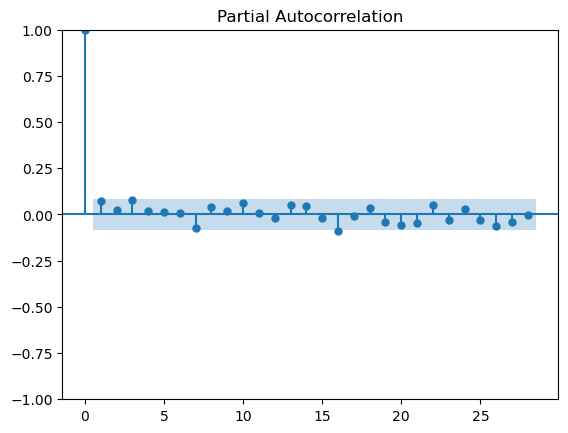

In [6]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

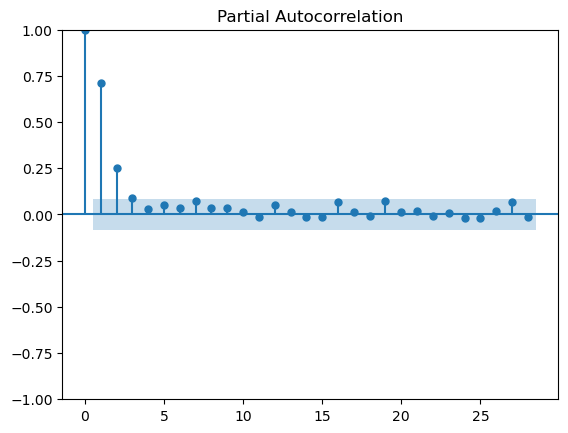

In [7]:
import statsmodels.tsa

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

In [8]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.07357706113792756), pvalue=np.float64(0.0927821717029524))

In [9]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.7127435059634651), pvalue=np.float64(2.790796762742914e-82))

In [10]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-2).iloc[:-2], ab_params_df['b'].iloc[:-2])

SignificanceResult(statistic=np.float64(0.6225234930822005), pvalue=np.float64(2.4508023703742948e-57))

In [11]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(-0.01989448326436393), pvalue=np.float64(0.6498812934764181))

In [12]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)



In [13]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1']))


0.5080441178142545
0.006823702314881164


In [14]:
ab_params_df['shifted_a_2'] = ab_params_df['a'].shift(-2)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)

In [15]:
r_b = LinearRegression()

r_b.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2'])
print(r_b.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2']))

r_a = LinearRegression()

r_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2'])
print(r_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2']))


0.5436764768515916
0.007599308630118484


In [16]:
r_b.coef_

array([ 0.20132706,  0.26513434, -0.07565564,  0.5277052 ])

In [17]:
lr_b.coef_

array([0.02420741, 0.7150007 ])

In [18]:
lr_a.coef_

array([0.07448129, 0.01094682])

In [19]:
r_a.coef_

array([0.02655939, 0.00426529, 0.07115014, 0.00818354])

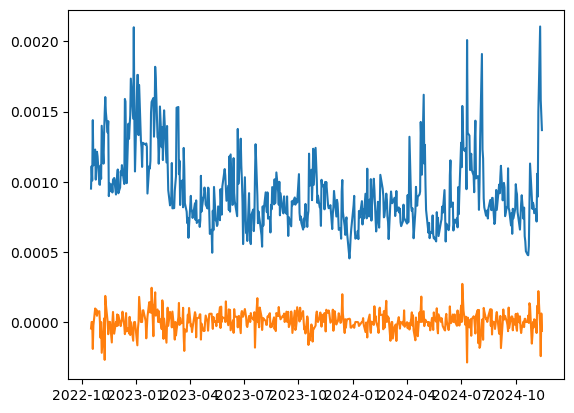

In [20]:
plt.plot(ab_params_df['b'])
plt.plot(ab_params_df['a'])

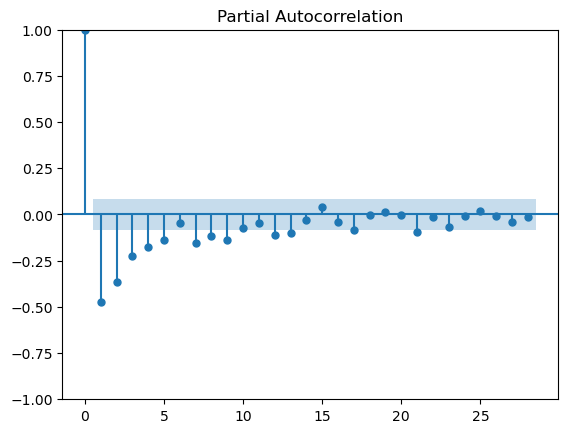

In [21]:
statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a'].diff()[1:]
)
plt.show()

In [22]:
replicates = 100000

In [23]:
possible_final_returns = np.zeros(replicates)
for r in tqdm(range(replicates)):
    samples = np.random.laplace(
        loc=r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1], 
        scale=r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1],
        size=len(ticker_hist_date)
    )

    possible_final_returns[r] = samples.sum()


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [01:30<00:00, 1109.39it/s]


In [24]:
r_a.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna())[-1]

np.float64(7.517552294953696e-06)

In [25]:
r_b.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna())[-1]

np.float64(0.0013198969361626033)

In [26]:
np.std(possible_final_returns)

np.float64(0.03694961432429786)

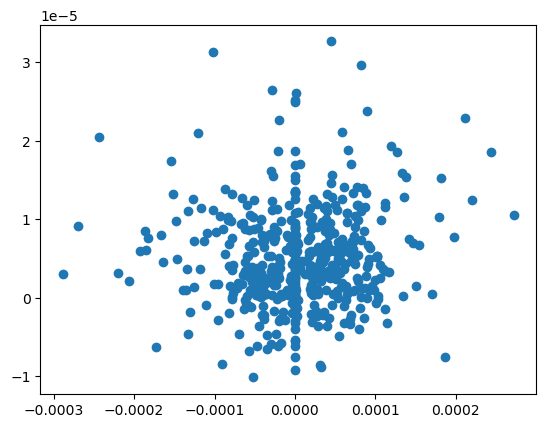

In [27]:
plt.scatter(
    ab_params_df.dropna()['shifted_a_2'], 
    r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]
    )
)

(450.0, 550.0)

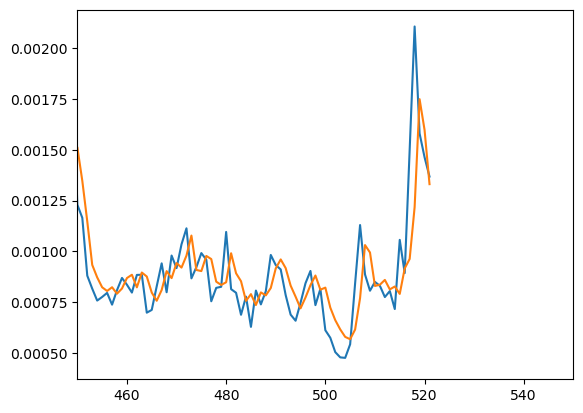

In [29]:
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True))
plt.plot(r_b.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]))

plt.xlim(450,550)

# declare spot ticker price

In [30]:
spot_spx_price = 307.

In [31]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_final_returns))

In [32]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))



308.1549284874712
11.39223947339282


In [33]:
upper_call = 330
lower_call = 320.
upper_put = 295.
lower_put = 285.

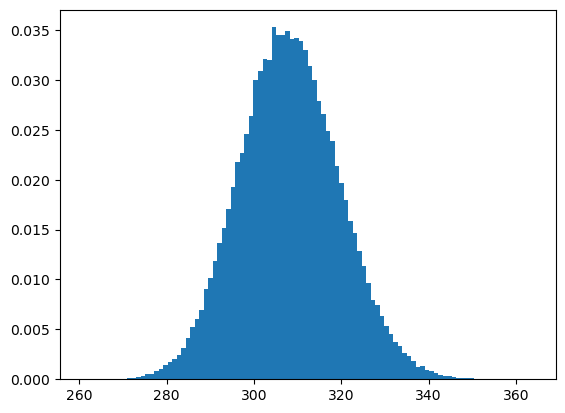

In [34]:
plt.hist(possible_final_prices, bins = 100, density = True)

plt.show()

In [35]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

Text(0.5, 1.0, 'avg payout is -1.36')

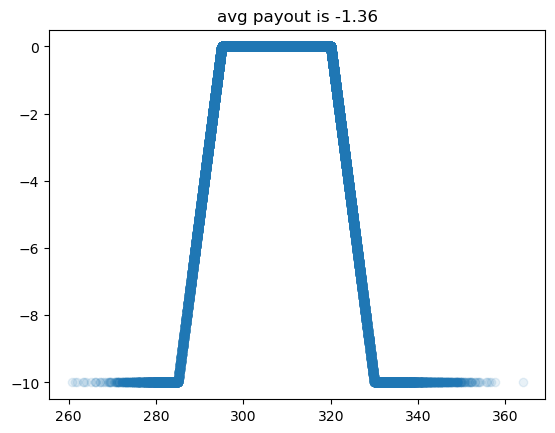

In [36]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

# compute cost of trade and max loss

In [62]:
cost_of_trade = 1.1
max_loss = 5

In [63]:
p = (max_loss - cost_of_trade)/max_loss

In [64]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is 2.220446049250313e-16


In [65]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.881181818181818
